In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
dataset_path = "/content/drive/MyDrive/Hoda 0-9"

print("Does the folder exist?", os.path.exists(dataset_path))
print("Dataset path:", dataset_path)

image_paths = glob.glob(
    os.path.join(dataset_path, "**", "*.bmp"),
    recursive=True
)

print("Number of BMP images found:", len(image_paths))
print("A few sample paths:")
print(image_paths[:5])


Does the folder exist? True
Dataset path: /content/drive/MyDrive/Hoda 0-9
Number of BMP images found: 1698
A few sample paths:
['/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_1162.bmp', '/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_1178.bmp', '/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_118.bmp', '/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_119.bmp', '/content/drive/MyDrive/Hoda 0-9/Hoda 0-9/4_12.bmp']


In [19]:
X_list = []
y_list = []

for img_path in image_paths:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img, (28, 28))

    file_name = os.path.basename(img_path)

    try:
        label = int(file_name.split("_")[0])
    except ValueError:
        continue

    if 0 <= label <= 9:
        X_list.append(img)
        y_list.append(label)

X_raw = np.array(X_list, dtype=np.float32)
y_raw = np.array(y_list, dtype=np.int64)

print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)
print("Number of images loaded:", len(X_raw))
print("Available classes:", np.unique(y_raw))


X_raw shape: (1698, 28, 28)
y_raw shape: (1698,)
Number of images loaded: 1698
Available classes: [0 1 2 3 4 5 6 7 8 9]


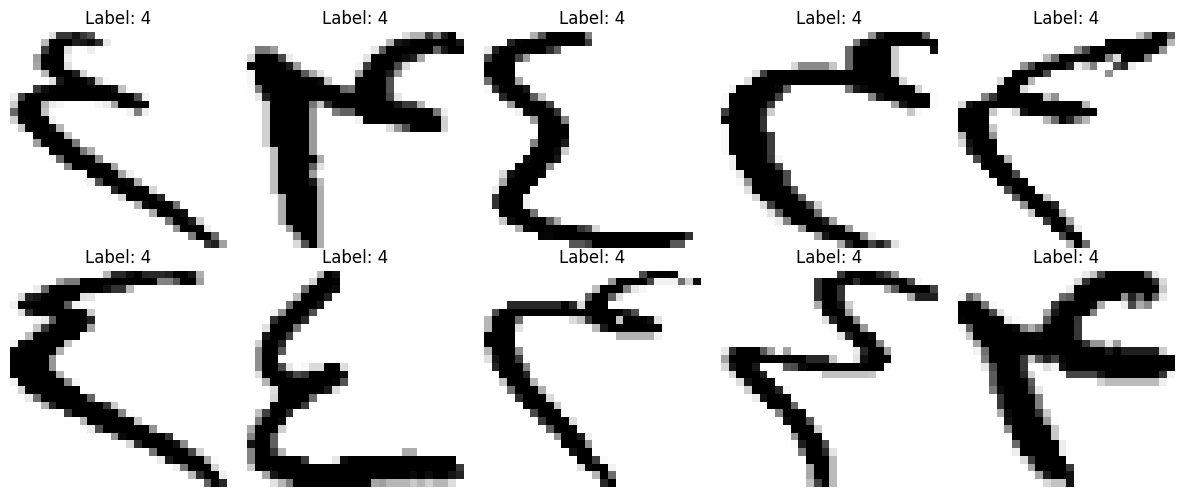

In [20]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_raw[i], cmap="gray")
    plt.title(f"Label: {y_raw[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
assert len(X_raw) > 0, "No images were loaded. Please check steps 2 and 3."

X = X_raw / 255.0

X = X.reshape(X.shape[0], -1)

y = np.eye(10)[y_raw]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_raw
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


X_train shape: (1358, 784)
y_train shape: (1358, 10)
X_test shape : (340, 784)
y_test shape : (340, 10)


In [21]:
class MultiClassMLP:
    def __init__(self, input_dim=784, hidden_dim=64, output_dim=10, lr=0.05):
        self.lr = lr

        # He initialization (suitable for ReLU)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

        self.losses = []

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def softmax(self, Z):

        # For numerical stability
        Z = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-12
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        return -np.mean(
            np.sum(y_true * np.log(y_pred), axis=1)
        )

    def forward(self, X):
        # Input layer -> Hidden layer
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.relu(self.Z1)

        # Hidden layer -> Output layer
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.softmax(self.Z2)

        return self.A2

    def backward(self, X, y_true, y_pred):
        n_samples = X.shape[0]

        # Output layer gradients
        dZ2 = (y_pred - y_true) / n_samples
        dW2 = self.A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer gradients
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update weights and biases
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=800, verbose=True):
        self.losses = []

        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)

            # Loss computation
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)

            # Backward pass
            self.backward(X, y, y_pred)

            # Print progress every 100 epochs
            if verbose and ((epoch + 1) % 100 == 0 or epoch == 0):
                print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss:.4f}")

    def predict(self, X):
        probabilities = self.forward(X)
        return np.argmax(probabilities, axis=1)


Epoch 1/800 - Loss: 2.5456
Epoch 100/800 - Loss: 0.4633
Epoch 200/800 - Loss: 0.2964
Epoch 300/800 - Loss: 0.2238
Epoch 400/800 - Loss: 0.1767
Epoch 500/800 - Loss: 0.1429
Epoch 600/800 - Loss: 0.1171
Epoch 700/800 - Loss: 0.0970
Epoch 800/800 - Loss: 0.0812


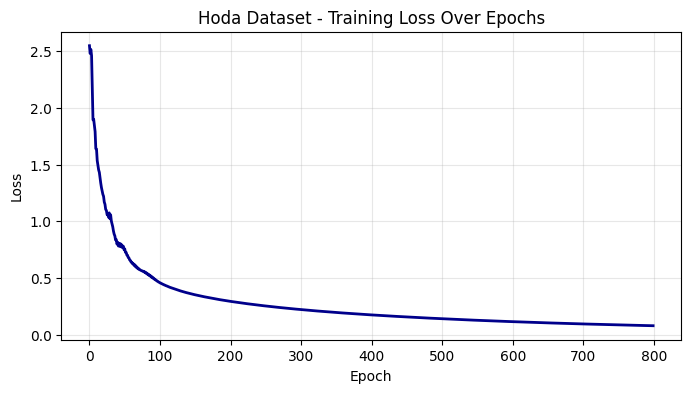

In [22]:

model = MultiClassMLP(
    input_dim=784,
    hidden_dim=64,
    output_dim=10,
    lr=0.05
)

model.fit(X_train, y_train, epochs=800, verbose=True)

plt.figure(figsize=(8, 4))
plt.plot(model.losses, color="darkblue", lw=2)
plt.title("Hoda Dataset - Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()


In [23]:

y_pred = model.predict(X_test)

y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 85.59%


              precision    recall  f1-score   support

           0       0.88      0.83      0.85        35
           1       0.89      0.91      0.90        34
           2       0.78      0.94      0.85        33
           3       0.84      0.91      0.87        34
           4       0.85      0.83      0.84        35
           5       0.88      0.85      0.87        34
           6       0.79      0.66      0.72        35
           7       0.81      0.88      0.85        34
           8       0.94      0.88      0.91        34
           9       0.93      0.88      0.90        32

    accuracy                           0.86       340
   macro avg       0.86      0.86      0.86       340
weighted avg       0.86      0.86      0.85       340



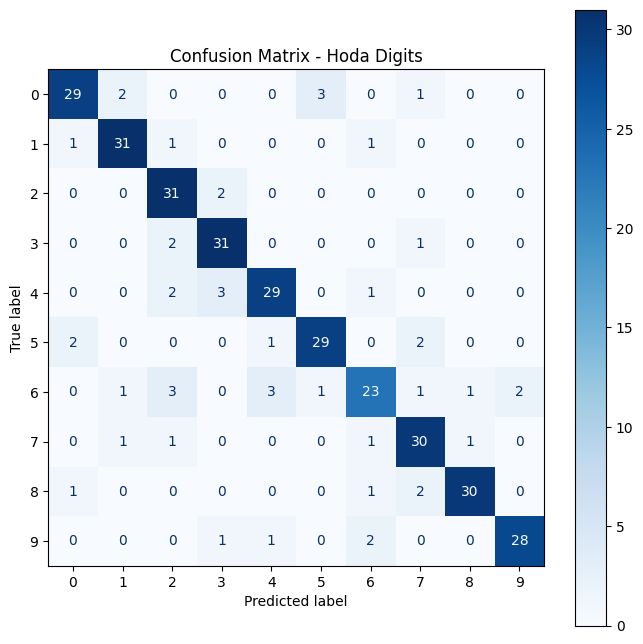

In [24]:

print(classification_report(y_true, y_pred))


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Hoda Digits")
plt.show()


In [25]:
import pickle
import os

# Define export directory and file path
export_dir = "/content/drive/MyDrive/Hoda 0-9"
os.makedirs(export_dir, exist_ok=True)
export_path = os.path.join(export_dir, "hoda_mlp_model.pkl")

# Save model object containing weights and architecture parameters
with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Model successfully saved to: {export_path}")


Model successfully saved to: /content/drive/MyDrive/Hoda 0-9/hoda_mlp_model.pkl


In [26]:
# Load the saved model from disk
with open(export_path, "rb") as f:
    loaded_model = pickle.load(f)

print(f"Model successfully loaded from: {export_path}")

# Run inference test on 5 unseen test samples
sample_X = X_test[:5]
sample_y_true = np.argmax(y_test[:5], axis=1)

sample_preds = loaded_model.predict(sample_X)

print("\n--- Model Verification & Inference Test ---")
for i in range(len(sample_y_true)):
    probs = loaded_model.forward(sample_X[i].reshape(1, -1))[0]
    confidence = probs[sample_preds[i]] * 100
    status = "CORRECT" if sample_preds[i] == sample_y_true[i] else "INCORRECT"
    print(f"Sample {i+1}: True Digit = {sample_y_true[i]} | Predicted = {sample_preds[i]} ({confidence:.2f}%) | [{status}]")

Model successfully loaded from: /content/drive/MyDrive/Hoda 0-9/hoda_mlp_model.pkl

--- Model Verification & Inference Test ---
Sample 1: True Digit = 3 | Predicted = 3 (78.98%) | [CORRECT]
Sample 2: True Digit = 9 | Predicted = 9 (97.94%) | [CORRECT]
Sample 3: True Digit = 4 | Predicted = 3 (41.61%) | [INCORRECT]
Sample 4: True Digit = 4 | Predicted = 4 (84.45%) | [CORRECT]
Sample 5: True Digit = 8 | Predicted = 8 (97.84%) | [CORRECT]
